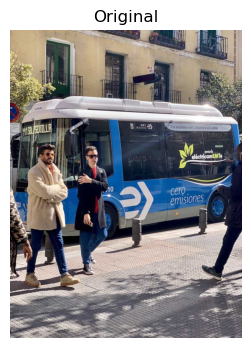

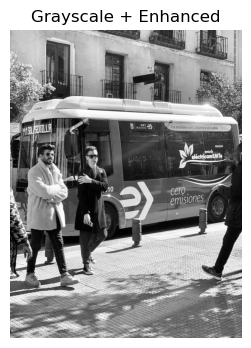

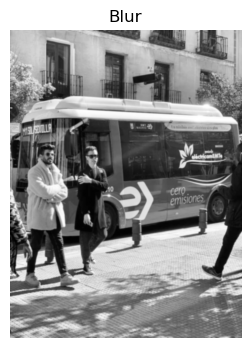

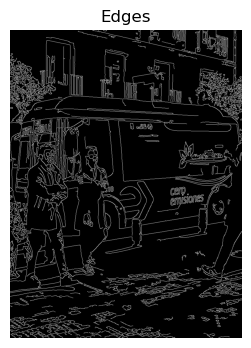

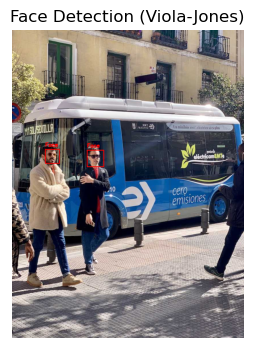

✅ Faces detected: 2


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(title, img, cmap=None):
    plt.figure(figsize=(6,4))
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

image_path = r"C:\Users\Janane S B\Downloads\input.jpg.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("❌ Image not loaded")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original = image.copy()

show("Original", image)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Improve contrast
gray = cv2.equalizeHist(gray)

show("Grayscale + Enhanced", gray, cmap='gray')


blur = cv2.GaussianBlur(gray, (7, 7), 0)
show("Blur", blur, cmap='gray')


edges = cv2.Canny(blur, 50, 150)
show("Edges", edges, cmap='gray')

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.05,   # 🔥 more sensitive
    minNeighbors=4,     # balance accuracy
    minSize=(30,30)
)

vj_output = original.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(vj_output, (x,y), (x+w, y+h), (255,0,0), 2)
    cv2.putText(vj_output, "Face",
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (255,0,0), 2)

show("Face Detection (Viola-Jones)", vj_output)

print("✅ Faces detected:", len(faces))